In [51]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor
import numpy as np
from sklearn.utils import resample
pd.set_option('display.max_columns', None)

In [52]:
import pandas as pd
from sklearn.utils import resample

def balance_regression_tail(
    df,
    target,
    threshold=0.5,
    majority_ratio=3,
    random_state=42
):
    """
    Downsample majority class for regression targets.

    Keeps all rows where target > threshold,
    samples majority rows to desired ratio.

    Returns shuffled, clean-index dataframe.
    """

    # Split groups
    minority = df[df[target] > threshold]
    majority = df[df[target] <= threshold]

    if len(minority) == 0:
        raise ValueError("No minority samples found.")

    desired_majority = min(
        len(majority),
        len(minority) * majority_ratio
    )

    majority_sampled = resample(
        majority,
        replace=False,
        n_samples=desired_majority,
        random_state=random_state
    )

    balanced = (
        pd.concat([minority, majority_sampled], axis=0)
        .sample(frac=1, random_state=random_state)
        .reset_index(drop=True)
    )

    return balanced

In [53]:
df = pd.read_csv("trimmed_data")
df.head(3)

,Unnamed: 0,employee_id,role,job_level,department,tenure_months,salary,performance_score,satisfaction_score,workload_score,team_sentiment,recent_feedback,communication_patterns,project_completion_rate,overtime_hours,training_participation,collaboration_score,technical_skills,soft_skills,email_sentiment,slack_activity,meeting_participation,goal_achievement_rate,stress_level,burnout_risk,left_company,turnover_reason,risk_factors_summary,turnover_probability_generated,persona_name,role_complexity_score,career_progression_score
0,0,SYN_00420291,Product Manager,Manager,Legal,1,79576.529763,0.764073,0.911248,0.232791,0.680066,"AppleCare Advisor (AHA) Secondments, L&D cours...",Exhibits communication style typical of a Quie...,0.615943,24.856885,0.438119,0.666939,['dbt' 'REST APIs' 'Machine Learning Theory' '...,['Mentorship' 'Creativity' 'Conflict Resolutio...,0.905711,0.666939,0.666939,0.764073,0.976579,0.965075,False,Personal Reasons (Anomaly),Anomaly: High Satisfaction Flight Risk,0.804308,QuietAchiever,0.2,0.686203
1,1,SYN_00578974,,Mid,Procurement,1,72397.275467,1.000000,1.000000,0.282707,0.833099,"Great company, strong exec leadership Service ...",Exhibits communication style typical of a Over...,0.800000,7.541410,0.200199,0.833099,['ETL/ELT Pipelines' 'REST APIs' 'Machine Lear...,['Communication' 'Emotional Intelligence' 'Pro...,1.000000,0.833099,0.833099,1.000000,1.000000,1.000000,True,Personal Reasons (Anomaly),Anomaly: High Satisfaction Flight Risk,0.724241,OverachievingSprinter,0.2,0.944167
2,2,SYN_00373306,Warehouse Worker,Mid,Analytics,71,129111.746410,0.617530,0.738454,0.384942,0.594712,Positive review for microsoft * DS is a leader...,Exhibits communication style typical of a Ambi...,0.494024,2.366091,0.298077,0.493062,['CSS3' 'Java (Spring Boot)' 'Webpack' 'REST A...,['Communication' 'Critical Thinking' 'Creativi...,0.755825,0.493062,0.493062,0.617530,1.000000,1.000000,True,Burnout / Work-Life Balance,Severe Burnout Risk,0.288756,AmbitiousClimber,0.2,1.000000


In [54]:
# df = balance_regression_tail(
#     df,
#     target="turnover_probability_generated",
#     threshold=0.5,
#     majority_ratio=3
# )

## Main Ridge Model

In [55]:
# DEFINE FEATURES
usable_features = [
    "job_level", "department",
    "tenure_months", "salary", "performance_score", "satisfaction_score",
    "workload_score", "team_sentiment", "project_completion_rate",
    "overtime_hours", "training_participation", "collaboration_score",
    "email_sentiment", "slack_activity", "meeting_participation",
    "goal_achievement_rate", "stress_level",
    "role_complexity_score", "career_progression_score"]

categorical_vars = ["job_level", "department"]

numerical_vars = [
    "tenure_months", "salary", "performance_score", "satisfaction_score",
    "workload_score", "team_sentiment", "project_completion_rate",
    "overtime_hours", "training_participation", "collaboration_score",
    "email_sentiment", "slack_activity", "meeting_participation",
    "goal_achievement_rate", "stress_level",
    "role_complexity_score", "career_progression_score"]


# DATA PREP
TARGET = "turnover_probability_generated"
X = df.drop(TARGET, axis=1)
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42)

# PREPROCESSING + MODELING PIPELINE
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_vars),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"),
         categorical_vars),])

model = Pipeline([
    ("preprocess", preprocess),
    ("ridge", Ridge(alpha=0.1))])


# TRAIN + PREDICT
model.fit(X_train, y_train)
y_pred = model.predict(X_test).clip(0, 1)


# EVALUATION
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("\nModel Performance")
print("-" * 35)
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")


# EXPECTED BENCHMARKS
# RMSE: 0.06 – 0.10
# R²  : 0.30 – 0.50
# MAE : 0.05 – 0.08


Model Performance
-----------------------------------
RMSE : 0.2033
R²   : 0.1151
MAE  : 0.1654


/Users/gracehecke/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


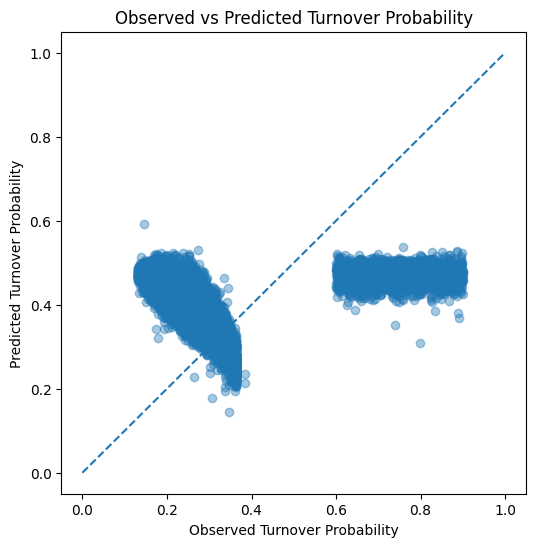

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.4)

# perfect prediction line
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("Observed Turnover Probability")
plt.ylabel("Predicted Turnover Probability")
plt.title("Observed vs Predicted Turnover Probability")

plt.show()

/var/folders/f8/lz99t7r51vz67ngmbyh9521w0000gn/T/ipykernel_75162/2866580945.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calibration = results.groupby("bin").agg(


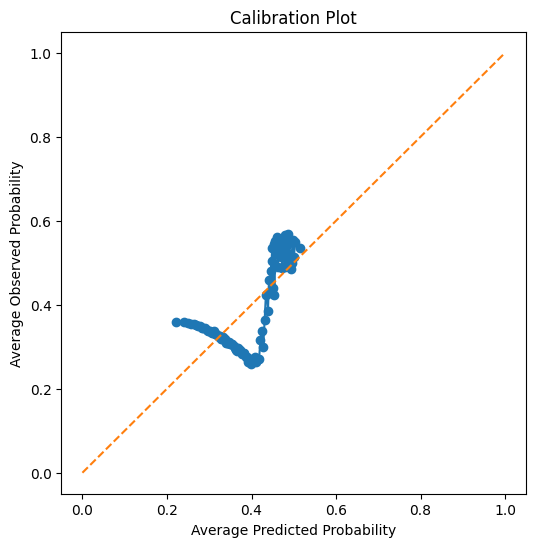

In [57]:
results = pd.DataFrame({
    "Observed": y_test,
    "Predicted": y_pred
}).reset_index(drop=True)

results["bin"] = pd.qcut(results["Predicted"], q=100)

calibration = results.groupby("bin").agg(
    observed_mean=("Observed", "mean"),
    predicted_mean=("Predicted", "mean")
)

plt.figure(figsize=(6,6))
plt.plot(calibration["predicted_mean"],
         calibration["observed_mean"],
         marker="o")

plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("Average Predicted Probability")
plt.ylabel("Average Observed Probability")
plt.title("Calibration Plot")

plt.show()

In [58]:
pred_var_ratio = y_pred.var() / y_test.var()
print(f"Prediction variance / Actual variance: {pred_var_ratio:.3f}")

Prediction variance / Actual variance: 0.122


## Model Comparison
### These include weighting for turnover probs over .05

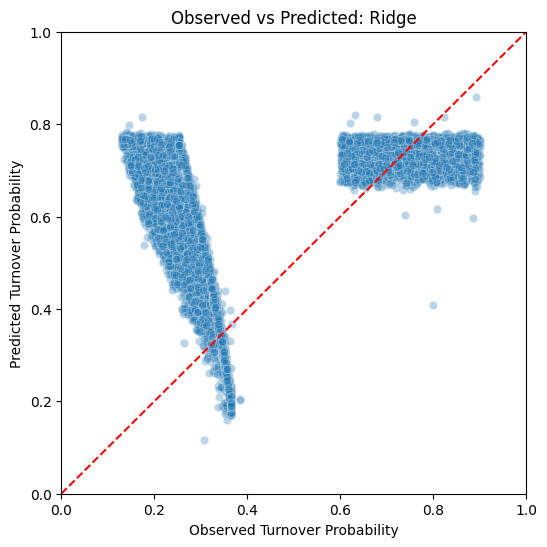

/Users/gracehecke/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


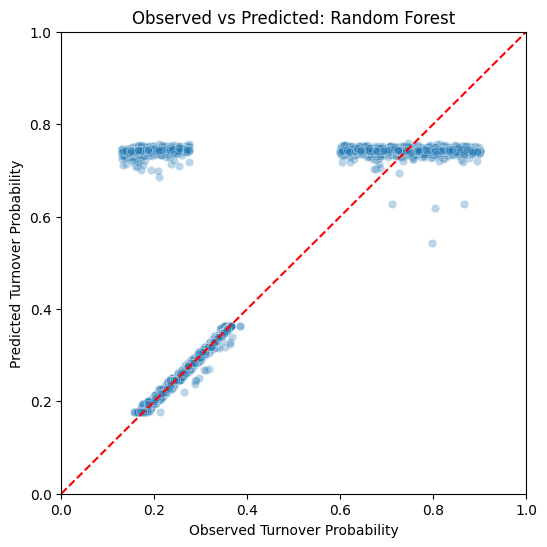

/Users/gracehecke/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


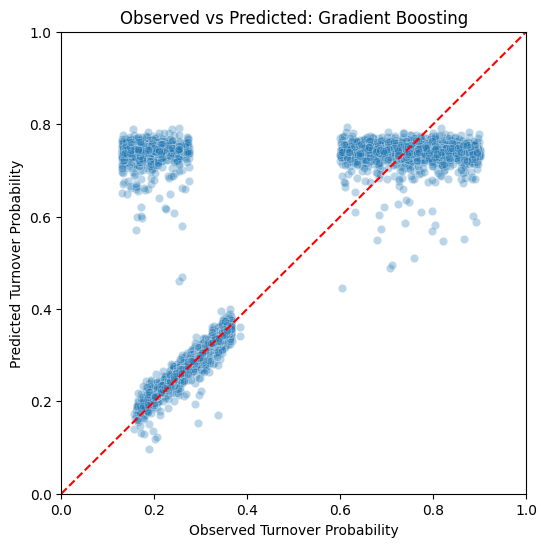

/Users/gracehecke/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


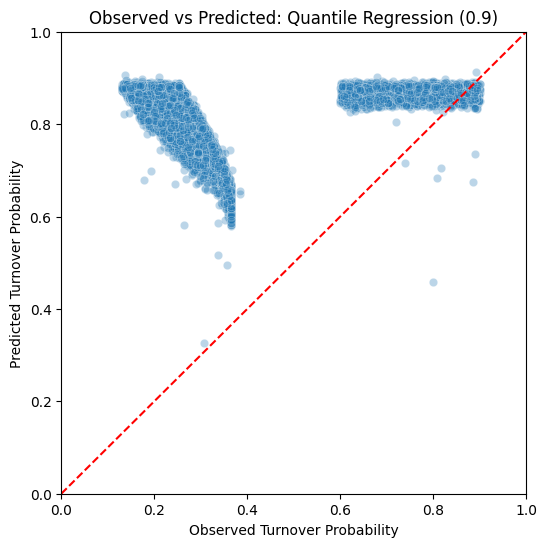


Model Comparison
--------------------------------------------------
Ridge
   RMSE: 0.2850
   R2: -0.7389
   MAE: 0.2161
   Predicted Variance / Actual Variance: 0.6573
--------------------------------------------------
Random Forest
   RMSE: 0.2284
   R2: -0.1167
   MAE: 0.1102
   Predicted Variance / Actual Variance: 1.0295
--------------------------------------------------
Gradient Boosting
   RMSE: 0.2279
   R2: -0.1119
   MAE: 0.1128
   Predicted Variance / Actual Variance: 1.0078
--------------------------------------------------
Quantile Regression (0.9)
   RMSE: 0.4497
   R2: -3.3290
   MAE: 0.4016
   Predicted Variance / Actual Variance: 0.1251
--------------------------------------------------


/Users/gracehecke/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [59]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import QuantileRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np
import seaborn as sns

# SAMPLE_SIZE = 20000  # adjust if smaller or larger works for you
# if len(X_train) > SAMPLE_SIZE:
#     train_idx = np.random.choice(X_train.index, SAMPLE_SIZE, replace=False)
#     test_idx = np.random.choice(X_test.index, SAMPLE_SIZE, replace=False)
    
#     X_train_sample = X_train.loc[train_idx]
#     y_train_sample = y_train.loc[train_idx]
#     X_test_sample = X_test.loc[test_idx]
#     y_test_sample = y_test.loc[test_idx]
# else:
#     X_train_sample, y_train_sample = X_train, y_train
#     X_test_sample, y_test_sample = X_test, y_test


sample_weights = np.ones(len(y_train))
sample_weights[y_train > 0.5] = 50

# MODELS TO TEST
models_to_test = {
    "Ridge": Ridge(alpha=0.1),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth = 6, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, max_depth = 4, random_state=42),
    "Quantile Regression (0.9)": QuantileRegressor(quantile=0.9, alpha=0)
}

results = {}

# SCATTER PLOT FUNCTION
def plot_observed_vs_predicted(y_true, y_pred, model_name):
    plt.figure(figsize=(6,6))
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.3)
    plt.plot([0,1],[0,1], color='red', linestyle='--')  # perfect prediction line
    plt.xlabel("Observed Turnover Probability")
    plt.ylabel("Predicted Turnover Probability")
    plt.title(f"Observed vs Predicted: {model_name}")
    plt.xlim(0,1)
    plt.ylim(0,1)
    plt.show()

for name, estimator in models_to_test.items():
    pipe = Pipeline([
        ("preprocess", preprocess),
        ("model", estimator)
    ])
    pipe.fit(X_train, y_train, model__sample_weight=sample_weights)
    y_pred_model = pipe.predict(X_test).clip(0, 1)

    plot_observed_vs_predicted(y_test, y_pred_model, name)
    
    rmse_model = mean_squared_error(y_test, y_pred_model, squared=False)
    r2_model = r2_score(y_test, y_pred_model)
    mae_model = mean_absolute_error(y_test, y_pred_model)
    
    # Variance ratio to see shrinkage/compression
    var_ratio = y_pred_model.var() / y_test.var()
    
    results[name] = {
        "RMSE": rmse_model,
        "R2": r2_model,
        "MAE": mae_model,
        "Predicted Variance / Actual Variance": var_ratio
    }

# PRINT COMPARISON
print("\nModel Comparison")
print("-" * 50)
for model_name, metrics in results.items():
    print(f"{model_name}")
    for k, v in metrics.items():
        print(f"   {k}: {v:.4f}")
    print("-" * 50)

## Distribution of Target Variable

<Axes: xlabel='turnover_probability_generated', ylabel='Count'>

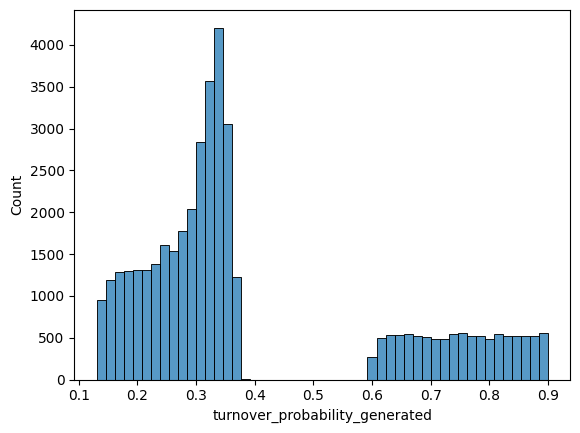

In [60]:
import seaborn as sns
sns.histplot(y_train, bins=50)

In [61]:
# Count how many employees are above or below 0.5
above_05 = (y > 0.5).sum()
below_05 = (y <= 0.5).sum()

total = len(y)

print(f"Total employees: {total}")
print(f"Turnover probability > 0.5: {above_05} ({above_05/total:.2%})")
print(f"Turnover probability <= 0.5: {below_05} ({below_05/total:.2%})")

# 50 samples
# 50 / 50 

Total employees: 51000
Turnover probability > 0.5: 12750 (25.00%)
Turnover probability <= 0.5: 38250 (75.00%)


In [62]:
df.to_csv("trimmed_data")